# AT1 - Perceptron Manual

Aluno: Lucas Miura  
Disciplina: Aprendizado de Máquina  

Dataset: McDonald's Historical Stock Price (Kaggle)

## Introdução

O Perceptron é um algoritmo de classificação binária utilizado em aprendizado de máquina.

Neste trabalho, foi implementado um Perceptron manual, sem uso de bibliotecas como numpy, com o objetivo de compreender seu funcionamento.

O problema consiste em prever se o preço de fechamento da ação da empresa McDonald's irá subir no próximo dia, com base em dados históricos.

## Base de Dados

O dataset foi obtido do Kaggle e contém dados históricos das ações da empresa McDonald's (MCD).

As variáveis disponíveis são:

- Date: data da negociação
- Open: preço de abertura
- High: maior preço do dia
- Low: menor preço do dia
- Close: preço de fechamento
- Volume: volume negociado

In [37]:
import pandas as pd

df = pd.read_csv("../data/raw/mcd.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,1/3/2000,21.041384,21.273702,20.676312,21.207325,4520600
1,1/4/2000,20.609928,21.008188,20.377610,20.875434,4216500
2,1/5/2000,20.941809,21.439633,20.609926,20.609926,5231600
3,1/6/2000,20.643116,20.908622,20.543551,20.775869,4809400
4,1/7/2000,21.174128,21.240504,20.643115,20.709492,5124700


In [38]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6559 entries, 0 to 6558
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6559 non-null   str    
 1   Close   6559 non-null   float64
 2   High    6559 non-null   float64
 3   Low     6559 non-null   float64
 4   Open    6559 non-null   float64
 5   Volume  6559 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 307.6 KB


,Close,High,Low,Open,Volume
count,6559.000000,6559.000000,6559.000000,6559.000000,6.559000e+03
mean,100.092901,100.838946,99.309031,100.071780,5.355927e+06
std,90.927747,91.569307,90.242097,90.910094,3.426558e+06
min,6.766116,6.859027,6.624016,6.787973,9.632000e+05
25%,20.726666,20.877495,20.479321,20.705098,3.183350e+06
50%,68.244904,68.648625,67.823615,68.205567,4.535200e+06
75%,164.342209,166.380339,162.950638,164.537825,6.500900e+06
max,319.649994,321.790008,318.350006,319.380005,8.698130e+07


In [39]:
df["target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
df = df.dropna()

## Definição do problema

Foi criada uma variável alvo (target) que indica:

- 1 → o preço de fechamento do próximo dia é maior (subiu)
- 0 → o preço não subiu

Isso transforma o problema em uma classificação binária.

## Escolha das variáveis de entrada

As variáveis escolhidas foram:

- Open: representa o preço inicial do dia
- Volume: representa a quantidade de negociações

Essas variáveis foram escolhidas por influenciarem o comportamento do preço ao longo do mercado.

In [40]:
x1 = list(df["Open"])
x2 = list(df["Volume"])
y = list(df["target"])

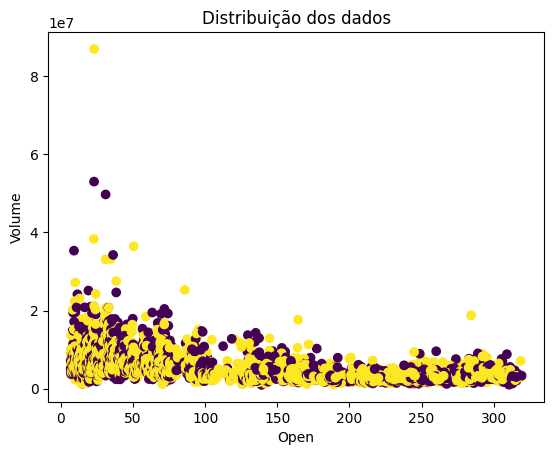

In [41]:
import matplotlib.pyplot as plt

plt.scatter(df["Open"], df["Volume"], c=df["target"])
plt.xlabel("Open")
plt.ylabel("Volume")
plt.title("Distribuição dos dados")
plt.show()

In [42]:
class Perceptron:
    def __init__(self, lr=0.00000001, epochs=20):
        self.lr = lr
        self.epochs = epochs
        self.w1 = 0
        self.w2 = 0
        self.bias = 0

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, x1, x2):
        soma = (x1 * self.w1) + (x2 * self.w2) + self.bias
        return self.activation(soma)

    def train(self, X1, X2, Y):
        for _ in range(self.epochs):
            for i in range(len(Y)):
                y_pred = self.predict(X1[i], X2[i])
                erro = Y[i] - y_pred

                self.w1 += self.lr * erro * X1[i]
                self.w2 += self.lr * erro * X2[i]
                self.bias += self.lr * erro

In [43]:
p = Perceptron()
p.train(x1, x2, y)

In [44]:
for i in range(10):
    print("Real:", y[i], "Previsto:", p.predict(x1[i], x2[i]))

Real: 0 Previsto: 0
Real: 1 Previsto: 0
Real: 0 Previsto: 0
Real: 1 Previsto: 0
Real: 1 Previsto: 0
Real: 1 Previsto: 0
Real: 1 Previsto: 0
Real: 0 Previsto: 0
Real: 1 Previsto: 0
Real: 0 Previsto: 0


In [45]:
print(p.predict(21, 5000000))

0


## Funcionamento do Perceptron

O modelo calcula uma soma ponderada das entradas:

soma = (x1 * w1) + (x2 * w2) + bias

Se o resultado for maior ou igual a 0:
→ saída 1 (preço sobe)

Caso contrário:
→ saída 0 (preço não sobe)

## Conclusão

O modelo foi capaz de identificar padrões simples nos dados históricos das ações.

Apesar de ser um modelo linear, o Perceptron demonstra como algoritmos de aprendizado de máquina funcionam na prática.

Este tipo de abordagem pode ser utilizado em análises iniciais de mercado financeiro.